# KNN classifier
> breast_cancer.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

In [2]:
df = pd.read_csv('breast_cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# removing the unnecessary columns
df = df.drop(columns=['id','Unnamed: 32'])
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [4]:
# featues and target
x = df.iloc[: ,1:]
y = df.iloc[:, 0]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [5]:
# encoding the target column
encoder = LabelEncoder()
encoder.fit_transform(y)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

In [6]:
# feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [7]:
# trying different values of k for max performance
import math
math.sqrt(df.shape[0])

23.853720883753127

## best K

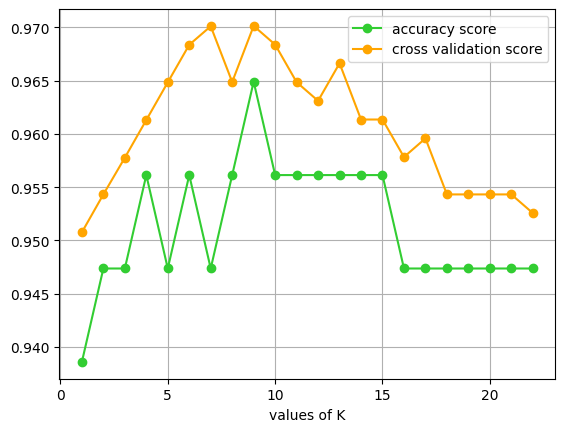

In [14]:
accuracy_list = []
cross_val_score_list = []

for i in range(1, 23):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train, y_train)
    y_Pred = knn.predict(x_test)

    accuracy_list.append(accuracy_score(y_test, y_Pred))
    cross_val_score_list.append(cross_val_score(knn, scaler.transform(x), y, cv = 5).mean())

plt.plot(range(1,23), accuracy_list, color = 'limegreen', marker = 'o', label = 'accuracy score')
plt.plot(range(1,23), cross_val_score_list, color = 'orange', marker = 'o', label = 'cross validation score')
plt.legend()
plt.xlabel('values of K')
# plt.ylabel('accuracy score')
plt.grid(True)
plt.show()

> best value of **<span style = 'color:orange'>k = 9**</span>

accuracy_score: 0.9649122807017544


              precision    recall  f1-score   support

           B       0.97      0.97      0.97        71
           M       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114





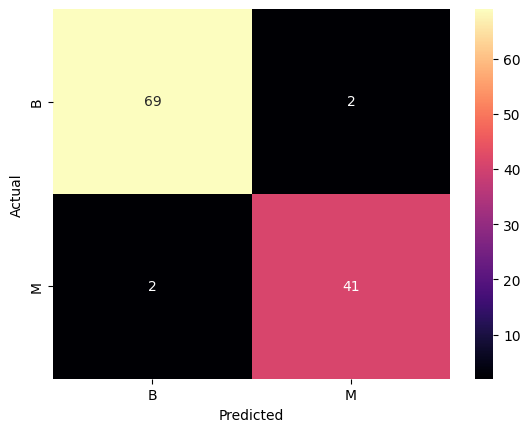

In [19]:
# model train
KNN = KNeighborsClassifier(n_neighbors=9)
KNN.fit(x_train, y_train)
y_pred = KNN.predict(x_test)

print('accuracy_score:',accuracy_score(y_test, y_pred))
print('\n')
print(classification_report(y_test, y_pred))
print('\n')
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, cmap = 'magma', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

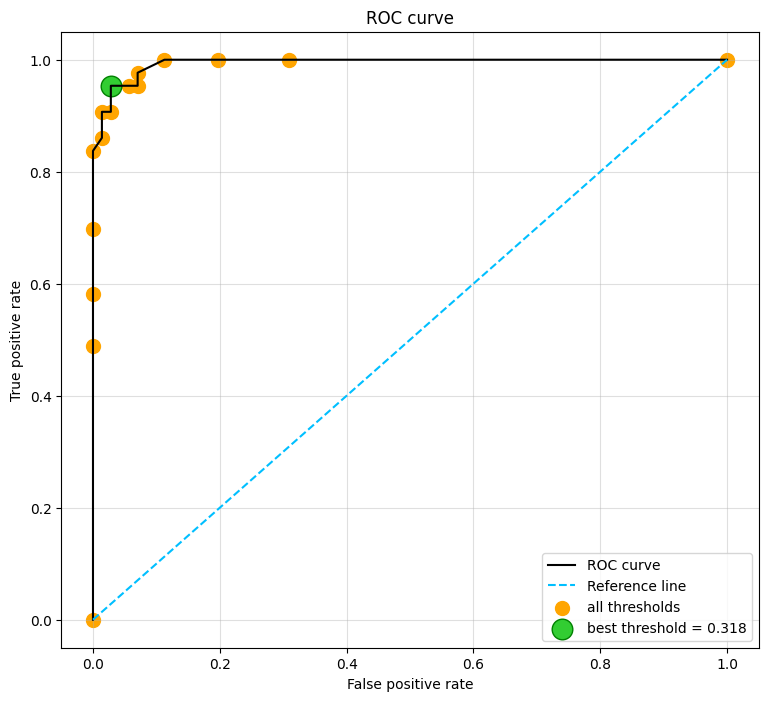

In [26]:
# ROC curve
y_score = knn.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score, pos_label='M') # positive label is M

# optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(9,8))
plt.plot(fpr, tpr, label = 'ROC curve', color = 'k')
plt.plot([0,1], [0,1], label = 'Reference line', ls = 'dashed', color = 'deepskyblue')
plt.scatter(fpr, tpr, label = 'all thresholds', color = 'orange', s = 100)
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], label = f'best threshold = {optimal_threshold:.3f}', s = 220, color = 'limegreen',edgecolors='green')


plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve')
plt.grid(axis='both', alpha = 0.4)
plt.legend()
plt.show()

In [27]:
print(roc_auc_score(y_test, y_score))

0.9941041598427776


In [29]:
from mlxtend.plotting import plot_decision_regions

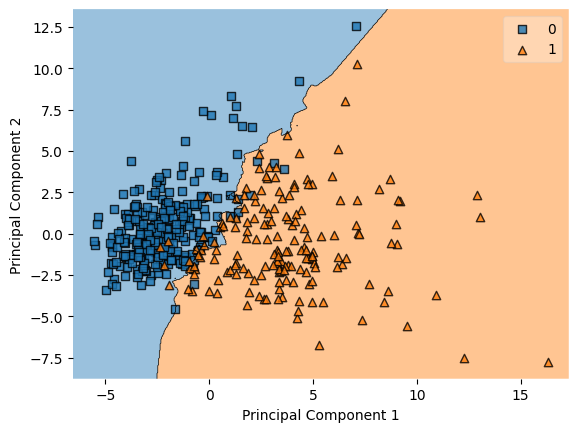

In [31]:
# deicision boundry

# encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# feature scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# pca
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)


# data split
x_train, x_test, y_train, y_test = train_test_split(x_pca,y, test_size=0.2, random_state=42)

# train
Knn = KNeighborsClassifier(n_neighbors=9)
Knn.fit(x_train, y_train)

plot_decision_regions(x_train, y_train, clf = Knn, legend=1)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [ ]:
# decision boundry
